# Multimodal LoReFT: Rank Pruning and Ablation Studies Analysis

This notebook analyzes the results from two types of experiments:
1. **Rank Pruning Experiments**: Analysis of how matrix ranks evolve during training with different initializations
2. **Ablation Studies**: Comparison of model performance with different components disabled

We'll create visualizations to understand these experiments and extract insights about model behavior.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
from IPython.display import display, HTML

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('notebook')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14

## 1. Rank Pruning Experiments

In these experiments, we track how the effective rank of representation matrices (R_s, R_m1, R_m2) changes during training due to pruning.

In [4]:
# Set the results directory path for rank pruning experiments
rank_results_dir = './results/pruning_sweep*train.csv'

# Find all CSV files matching the pattern
rank_files = glob.glob(rank_results_dir)
print(f"Found {len(rank_files)} rank pruning training files")

# Load all the rank pruning training data
rank_dfs = []
for file in rank_files:
    df = pd.read_csv(file)
    # Add filename as a column for tracking
    df['source_file'] = os.path.basename(file)
    rank_dfs.append(df)

# Combine all rank pruning data
if rank_dfs:
    rank_df = pd.concat(rank_dfs, ignore_index=True)
    print(f"Loaded rank pruning data: {rank_df.shape[0]} rows, {rank_df.shape[1]} columns")
    # Extract additional parameters from filenames if needed
    rank_df['experiment'] = 'rank_pruning'
    display(rank_df.head())
else:
    rank_df = None
    print("No rank pruning data found.")

Found 3 rank pruning training files
Loaded rank pruning data: 153117 rows, 19 columns


,Shared Loss,Orthogonal Loss,Mutual Info Loss,lr,stage,rank Rs,rank Rm1,rank Rm2,pruning,epoch,batch_size,learning_rate,lr_annealing,weight_decay,specific_rank,shared_rank,patience1,patience2,source_file,experiment
0,0.689409,5.313438,5.231964,0.00001,shared,2,2,2,0,0,128,0.00001,cosine,0,2,2,20,50,pruning_sweep_v1_seed346_sim_100000_in5-5_data...,rank_pruning
1,0.688647,5.315964,5.231037,0.00001,shared,2,2,2,0,1,128,0.00001,cosine,0,2,2,20,50,pruning_sweep_v1_seed346_sim_100000_in5-5_data...,rank_pruning
2,0.687123,5.318565,5.230118,0.00001,shared,2,2,2,0,2,128,0.00001,cosine,0,2,2,20,50,pruning_sweep_v1_seed346_sim_100000_in5-5_data...,rank_pruning
3,0.683467,5.321225,5.224687,0.00001,shared,2,2,2,0,3,128,0.00001,cosine,0,2,2,20,50,pruning_sweep_v1_seed346_sim_100000_in5-5_data...,rank_pruning
4,0.685442,5.323923,5.223161,0.00001,shared,2,2,2,0,4,128,0.00001,cosine,0,2,2,20,50,pruning_sweep_v1_seed346_sim_100000_in5-5_data...,rank_pruning


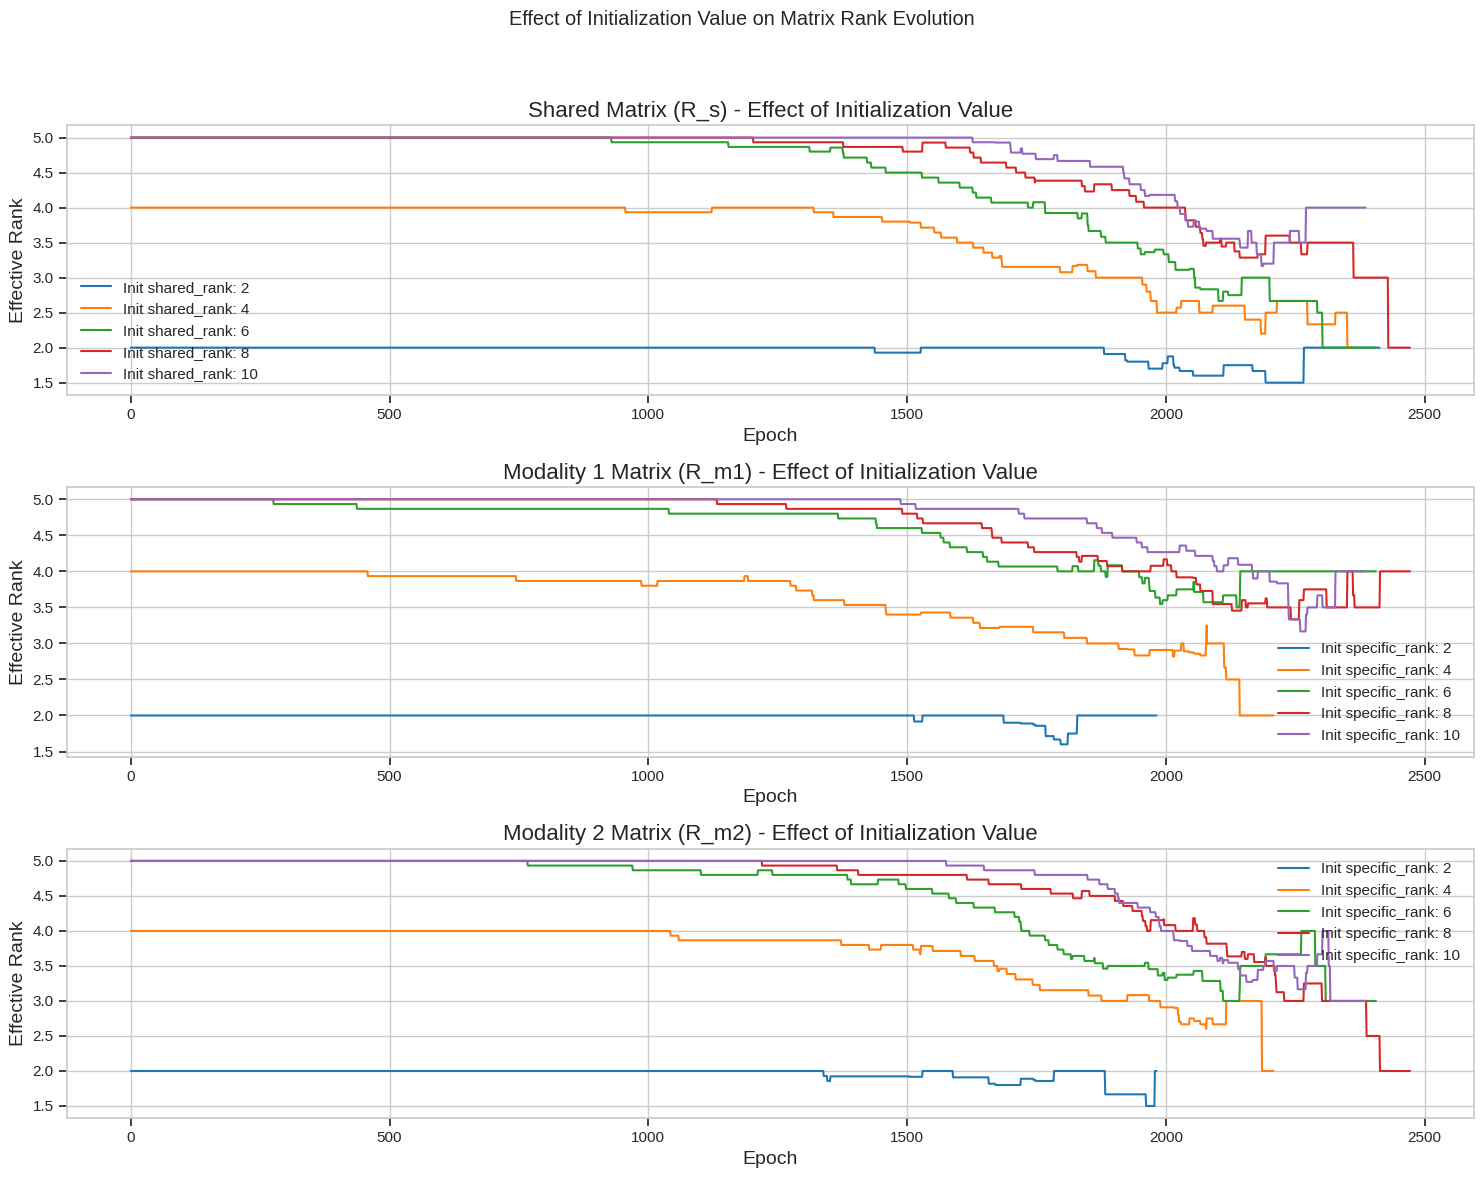

/tmp/ipykernel_809704/2474261499.py:48: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(x='shared_rank', y='rank Rs', data=last_epochs, ci='sd', marker='o')
/tmp/ipykernel_809704/2474261499.py:54: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(x='specific_rank', y='rank Rm1', data=last_epochs, ci='sd', marker='o')
/tmp/ipykernel_809704/2474261499.py:60: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(x='specific_rank', y='rank Rm2', data=last_epochs, ci='sd', marker='o')


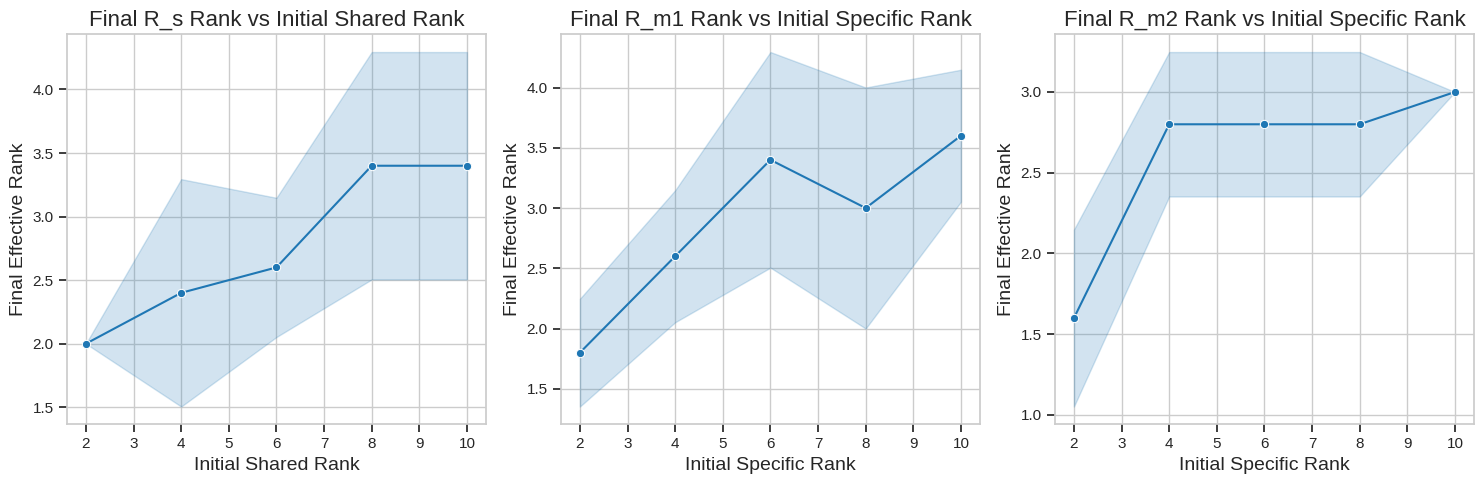

In [9]:
# Plot rank evolution over epochs for different starting ranks
if rank_df is not None and 'rank Rs' in rank_df.columns:
    # Group by starting shared and specific ranks
    rank_groups = rank_df.groupby(['shared_rank', 'specific_rank'])
    
    # Create subplots for different rank combinations
    unique_shared = sorted(rank_df['shared_rank'].unique())
    unique_specific = sorted(rank_df['specific_rank'].unique())
    
    matrix_names = ['rank Rs', 'rank Rm1', 'rank Rm2']
    titles = ['Shared Matrix (R_s)', 'Modality 1 Matrix (R_m1)', 'Modality 2 Matrix (R_m2)']
    
    # Plot rank evolution by initialization value
    if len(unique_shared) > 1 or len(unique_specific) > 1:
        plt.figure(figsize=(15, 12))
        for i, (matrix, title) in enumerate(zip(matrix_names, titles)):
            plt.subplot(3, 1, i+1)
            
            # Group by the relevant initial rank
            if matrix == 'rank Rs':
                key_rank = 'shared_rank'
            else:
                key_rank = 'specific_rank'
                
            for rank_val in sorted(rank_df[key_rank].unique()):
                subset = rank_df[rank_df[key_rank] == rank_val]
                # Average across all other factors (seeds, other rank values)
                avg_by_epoch = subset.groupby('epoch')[matrix].mean().reset_index()
                plt.plot(avg_by_epoch['epoch'], avg_by_epoch[matrix], '-', 
                        label=f'Init {key_rank}: {rank_val}')
                
            plt.title(f'{title} - Effect of Initialization Value')
            plt.xlabel('Epoch')
            plt.ylabel('Effective Rank')
            plt.legend()
            plt.grid(True)
            
        plt.suptitle('Effect of Initialization Value on Matrix Rank Evolution')
        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()
        
        # Plot the relationship between initial and final ranks
        plt.figure(figsize=(15, 5))
        # Extract last epoch for each experiment
        last_epochs = rank_df.loc[rank_df.groupby(['shared_rank', 'specific_rank'])['epoch'].idxmax()]
        
        plt.subplot(131)
        sns.lineplot(x='shared_rank', y='rank Rs', data=last_epochs, ci='sd', marker='o')
        plt.title('Final R_s Rank vs Initial Shared Rank')
        plt.xlabel('Initial Shared Rank')
        plt.ylabel('Final Effective Rank')
        
        plt.subplot(132)
        sns.lineplot(x='specific_rank', y='rank Rm1', data=last_epochs, ci='sd', marker='o')
        plt.title('Final R_m1 Rank vs Initial Specific Rank')
        plt.xlabel('Initial Specific Rank')
        plt.ylabel('Final Effective Rank')
        
        plt.subplot(133)
        sns.lineplot(x='specific_rank', y='rank Rm2', data=last_epochs, ci='sd', marker='o')
        plt.title('Final R_m2 Rank vs Initial Specific Rank')
        plt.xlabel('Initial Specific Rank')
        plt.ylabel('Final Effective Rank')
        
        plt.tight_layout()
        plt.show()
    
    # Plot final rank distribution
    # Extract last epoch for each experiment
    last_epochs = rank_df.loc[rank_df.groupby(['shared_rank', 'specific_rank'])['epoch'].idxmax()]
else:
    print("No rank evolution data available for plotting.")

## 2. Ablation Studies

In these experiments, we systematically disable different components of the model to understand their impact:
- Training stages (joint vs. staged training)
- Pruning (enabled vs. disabled)
- Loss normalization method
- Mutual information loss vs. reconstruction loss

In [10]:
# Set the results directory path for ablation studies
ablation_dir = './results/*ablation*'

# Find all CSV files for each metric
ablation_regression_files = glob.glob(ablation_dir + '*regression.csv')
ablation_classification_files = glob.glob(ablation_dir + '*classification.csv')
ablation_rank_files = glob.glob(ablation_dir + '*rank.csv')
ablation_train_files = glob.glob(ablation_dir + '*train.csv')

print(f"Found regression files: {len(ablation_regression_files)}")
print(f"Found classification files: {len(ablation_classification_files)}")
print(f"Found rank files: {len(ablation_rank_files)}")
print(f"Found training files: {len(ablation_train_files)}")

# Load regression data
ablation_regression_dfs = []
for file in ablation_regression_files:
    df = pd.read_csv(file)
    df['source_file'] = os.path.basename(file)
    ablation_regression_dfs.append(df)

if ablation_regression_dfs:
    ablation_regression_df = pd.concat(ablation_regression_dfs, ignore_index=True)
    print(f"Loaded ablation regression data: {ablation_regression_df.shape[0]} rows, {ablation_regression_df.shape[1]} columns")
    ablation_regression_df['experiment'] = 'ablation'
    display(ablation_regression_df.head())
else:
    ablation_regression_df = None
    print("No ablation regression data found.")

# Load classification data
ablation_classification_dfs = []
for file in ablation_classification_files:
    df = pd.read_csv(file)
    df['source_file'] = os.path.basename(file)
    ablation_classification_dfs.append(df)

if ablation_classification_dfs:
    ablation_classification_df = pd.concat(ablation_classification_dfs, ignore_index=True)
    print(f"Loaded ablation classification data: {ablation_classification_df.shape[0]} rows, {ablation_classification_df.shape[1]} columns")
    ablation_classification_df['experiment'] = 'ablation'
    display(ablation_classification_df.head())
else:
    ablation_classification_df = None
    print("No ablation classification data found.")

# Load rank data
ablation_rank_correlation_dfs = []
for file in ablation_rank_files:
    df = pd.read_csv(file)
    df['source_file'] = os.path.basename(file)
    ablation_rank_correlation_dfs.append(df)

if ablation_rank_correlation_dfs:
    ablation_rank_correlation_df = pd.concat(ablation_rank_correlation_dfs, ignore_index=True)
    print(f"Loaded ablation rank data: {ablation_rank_correlation_df.shape[0]} rows, {ablation_rank_correlation_df.shape[1]} columns")
    ablation_rank_correlation_df['experiment'] = 'ablation'
    display(ablation_rank_correlation_df.head())
else:
    ablation_rank_correlation_df = None
    print("No ablation rank data found.")

Found regression files: 1
Found classification files: 1
Found rank files: 1
Found training files: 1
Loaded ablation regression data: 72 rows, 9 columns


,name,r2_mean,r2_std,seed,joint,pruning,lossnorm,mi_loss,source_file,experiment
0,Zm1,0.746479,0.169843,0,True,True,gradient,True,ablation_sweep_sim_100000_in5-5_data5-5_shared...,ablation
1,Zs1,0.477941,0.369469,0,True,True,gradient,True,ablation_sweep_sim_100000_in5-5_data5-5_shared...,ablation
2,(Zm+Zs)1,0.737353,0.169502,0,True,True,gradient,True,ablation_sweep_sim_100000_in5-5_data5-5_shared...,ablation
3,Zm2,0.855889,0.057794,0,True,True,gradient,True,ablation_sweep_sim_100000_in5-5_data5-5_shared...,ablation
4,Zs2,0.576932,0.272199,0,True,True,gradient,True,ablation_sweep_sim_100000_in5-5_data5-5_shared...,ablation


Loaded ablation classification data: 48 rows, 12 columns


,name,accuracy,precision,recall,f1,roc_auc,seed,joint,pruning,lossnorm,mi_loss,source_file,experiment
0,Zs1,0.998333,0.996875,1.000000,0.998425,0.998246,0,True,True,gradient,True,ablation_sweep_sim_100000_in5-5_data5-5_shared...,ablation
1,Zs2,1.000000,1.000000,1.000000,1.000000,1.000000,0,True,True,gradient,True,ablation_sweep_sim_100000_in5-5_data5-5_shared...,ablation
2,Zm1,0.998333,1.000000,0.996774,0.998374,0.998387,0,True,True,gradient,True,ablation_sweep_sim_100000_in5-5_data5-5_shared...,ablation
3,Zm2,0.951667,0.921418,0.993651,0.955915,0.949548,0,True,True,gradient,True,ablation_sweep_sim_100000_in5-5_data5-5_shared...,ablation
4,Zs1,0.966667,0.971525,0.964977,0.968174,0.966699,0,False,False,gradient,True,ablation_sweep_sim_100000_in5-5_data5-5_shared...,ablation


Loaded ablation rank data: 72 rows, 9 columns


,name,metric,value,seed,joint,pruning,lossnorm,mi_loss,source_file,experiment
0,R_s-R_m1,correlation,0.037274,0,True,True,gradient,True,ablation_sweep_sim_100000_in5-5_data5-5_shared...,ablation
1,R_s-R_m2,correlation,0.388275,0,True,True,gradient,True,ablation_sweep_sim_100000_in5-5_data5-5_shared...,ablation
2,R_m1-R_m2,correlation,0.101958,0,True,True,gradient,True,ablation_sweep_sim_100000_in5-5_data5-5_shared...,ablation
3,R_s,rank,2.000000,0,True,True,gradient,True,ablation_sweep_sim_100000_in5-5_data5-5_shared...,ablation
4,R_m1,rank,3.000000,0,True,True,gradient,True,ablation_sweep_sim_100000_in5-5_data5-5_shared...,ablation


/tmp/ipykernel_809704/3578057049.py:8: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='name', y='r2_mean', hue=ablation_param, data=ablation_regression_df,


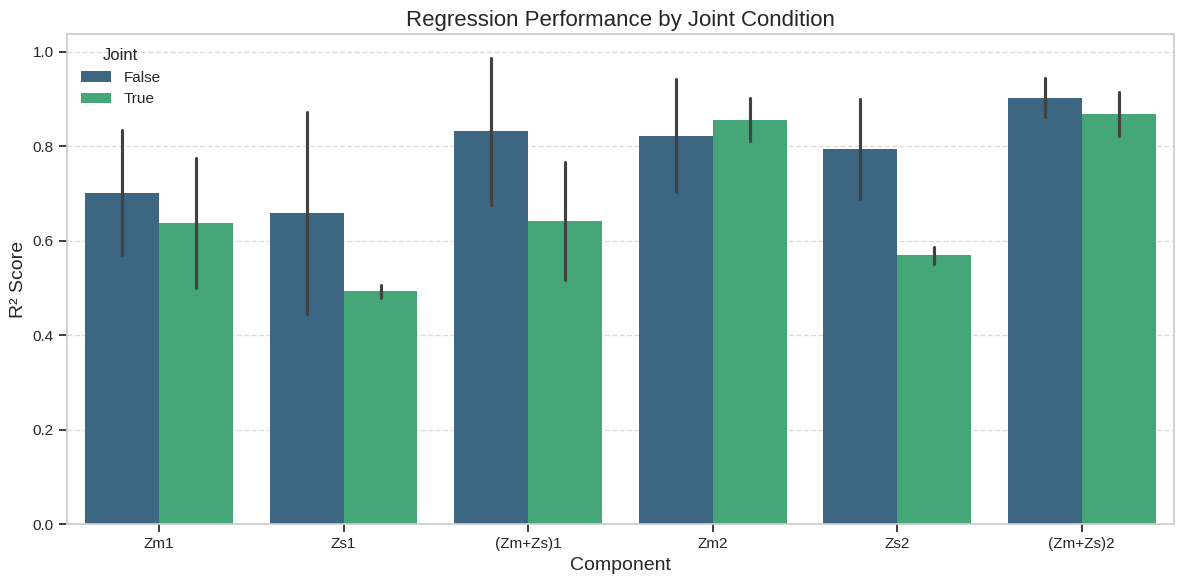

/tmp/ipykernel_809704/3578057049.py:8: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='name', y='r2_mean', hue=ablation_param, data=ablation_regression_df,


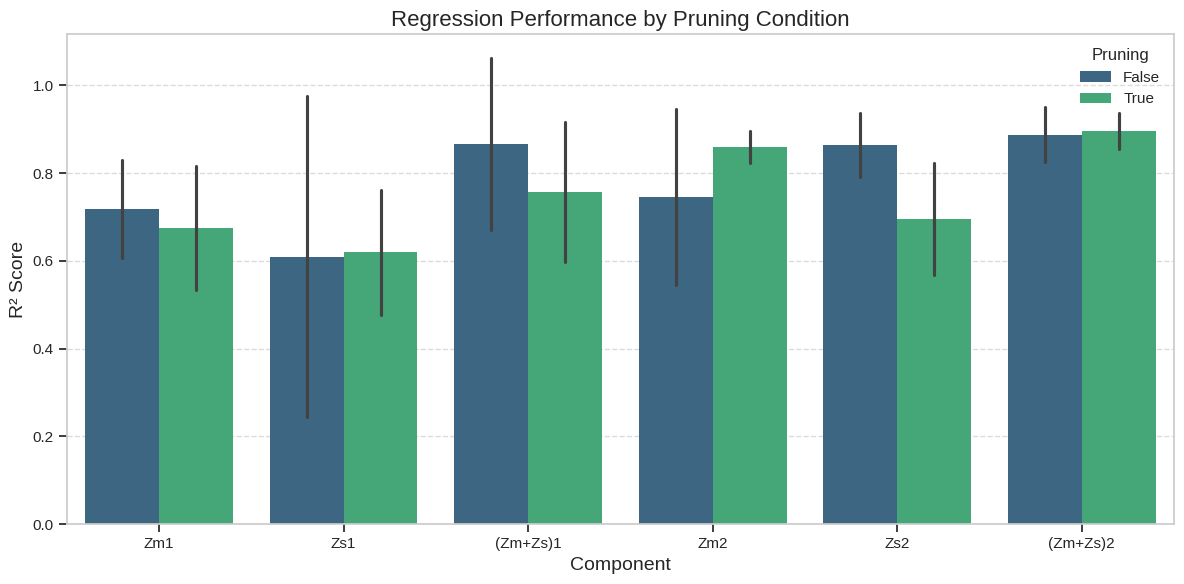

/tmp/ipykernel_809704/3578057049.py:8: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='name', y='r2_mean', hue=ablation_param, data=ablation_regression_df,


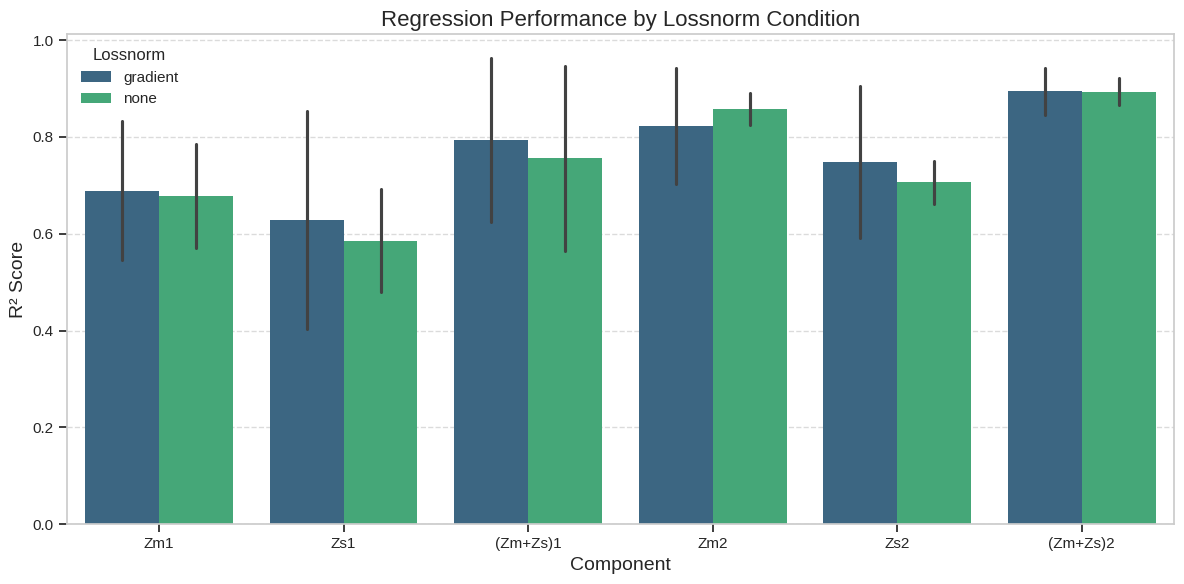

/tmp/ipykernel_809704/3578057049.py:8: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='name', y='r2_mean', hue=ablation_param, data=ablation_regression_df,


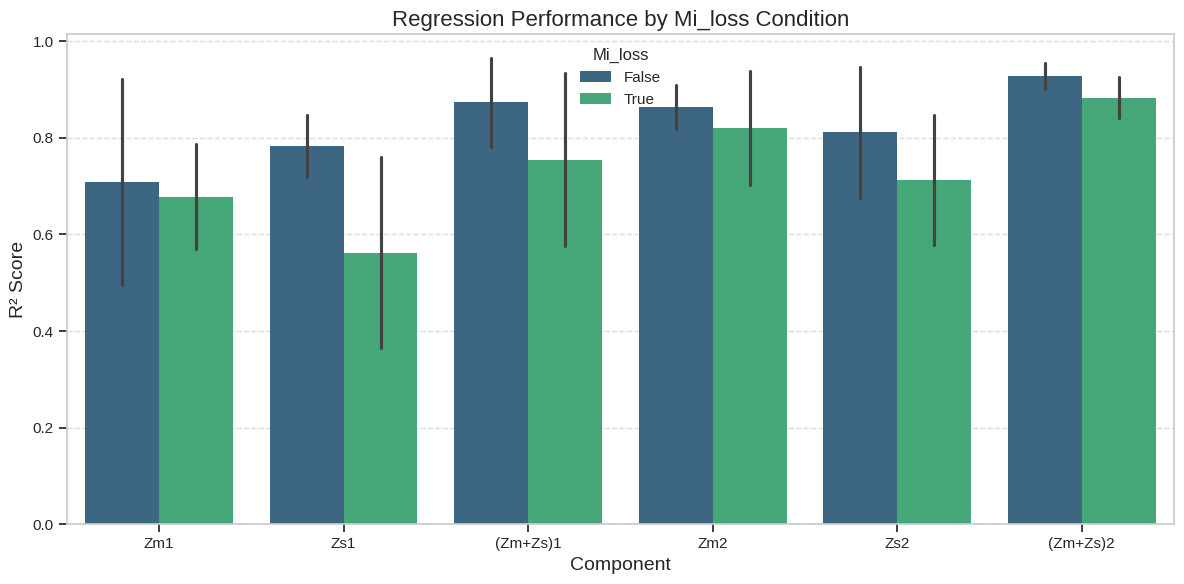

In [12]:
# Plot regression performance across ablation conditions
if ablation_regression_df is not None:
    # Primary comparisons
    for ablation_param in ['joint', 'pruning', 'lossnorm', 'mi_loss']:
        if ablation_param in ablation_regression_df.columns:
            plt.figure(figsize=(12, 6))
            # Using hue as ablation parameter to create grouped bar plots
            sns.barplot(x='name', y='r2_mean', hue=ablation_param, data=ablation_regression_df, 
                        palette='viridis', ci='sd')
            plt.title(f'Regression Performance by {ablation_param.capitalize()} Condition')
            plt.xlabel('Component')
            plt.ylabel('R² Score')
            plt.legend(title=ablation_param.capitalize())
            plt.grid(axis='y', linestyle='--', alpha=0.7)
            plt.tight_layout()
            plt.show()
else:
    print("No ablation regression data available for plotting.")

/tmp/ipykernel_809704/3893021162.py:8: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='name', y='accuracy', hue=ablation_param, data=ablation_classification_df,


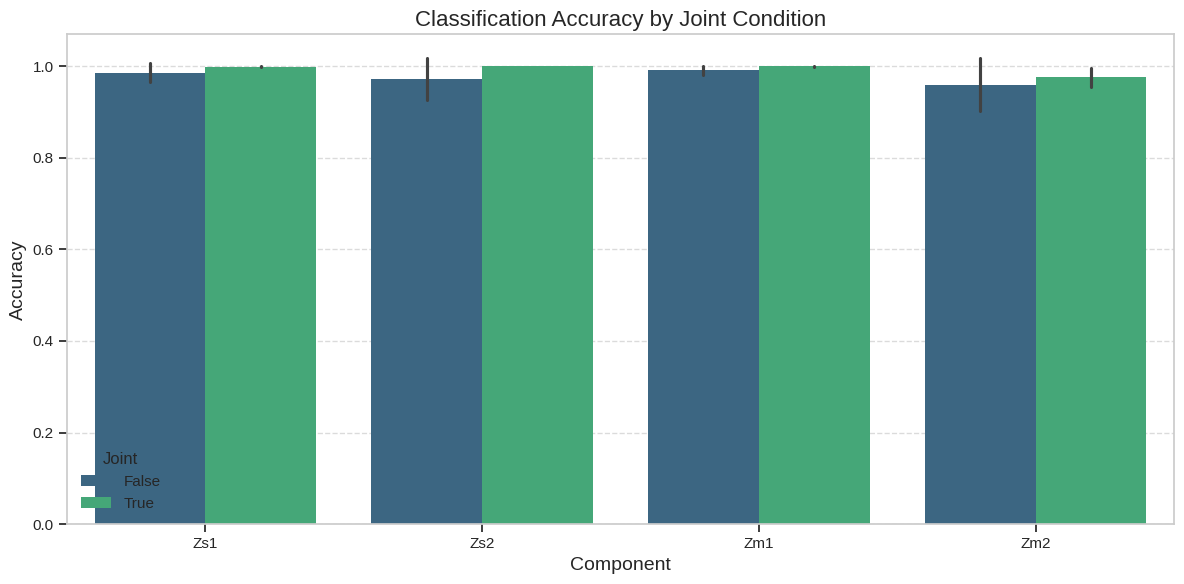

/tmp/ipykernel_809704/3893021162.py:8: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='name', y='accuracy', hue=ablation_param, data=ablation_classification_df,


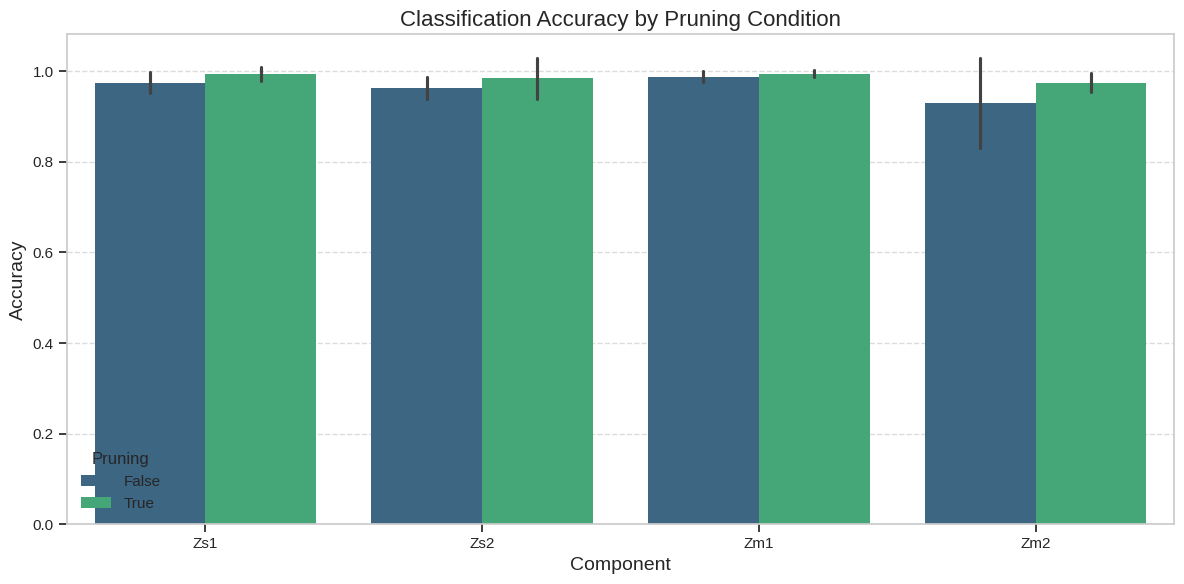

/tmp/ipykernel_809704/3893021162.py:8: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='name', y='accuracy', hue=ablation_param, data=ablation_classification_df,


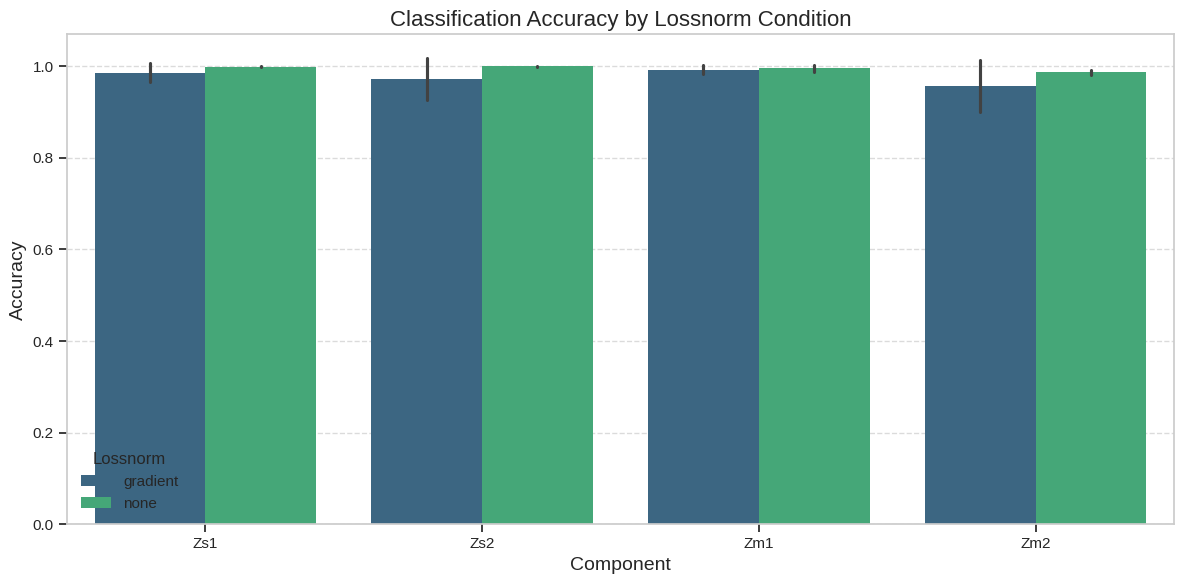

/tmp/ipykernel_809704/3893021162.py:8: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='name', y='accuracy', hue=ablation_param, data=ablation_classification_df,


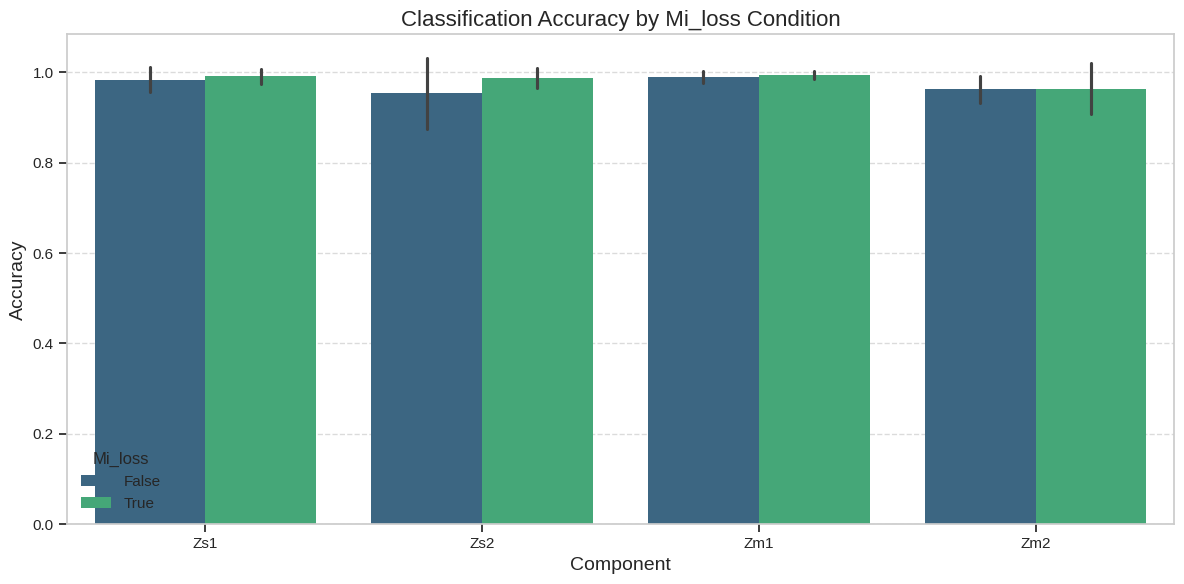

/tmp/ipykernel_809704/3893021162.py:26: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='component_type', y='accuracy', hue='mi_loss',


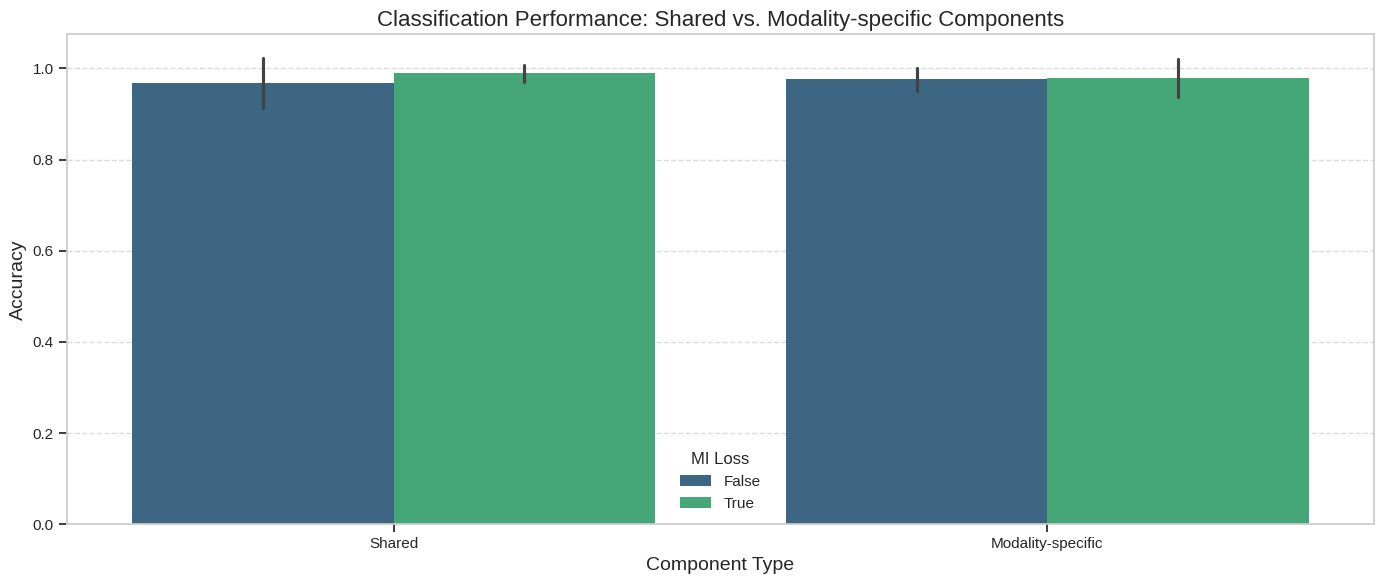

In [13]:
# Plot classification performance across ablation conditions
if ablation_classification_df is not None:
    # Primary comparisons
    for ablation_param in ['joint', 'pruning', 'lossnorm', 'mi_loss']:
        if ablation_param in ablation_classification_df.columns:
            plt.figure(figsize=(12, 6))
            # Using hue as ablation parameter to create grouped bar plots
            sns.barplot(x='name', y='accuracy', hue=ablation_param, data=ablation_classification_df, 
                        palette='viridis', ci='sd')
            plt.title(f'Classification Accuracy by {ablation_param.capitalize()} Condition')
            plt.xlabel('Component')
            plt.ylabel('Accuracy')
            plt.legend(title=ablation_param.capitalize())
            plt.grid(axis='y', linestyle='--', alpha=0.7)
            plt.tight_layout()
            plt.show()
    
    # Visualize shared vs. modality-specific performance
    plt.figure(figsize=(14, 6))
    # Create component type column
    ablation_classification_df['component_type'] = ablation_classification_df['name'].apply(
        lambda x: 'Shared' if 'Zs' in x else 'Modality-specific')
    
    # Create a combined plot of performance by component type and ablation
    if 'mi_loss' in ablation_classification_df.columns:
        sns.barplot(x='component_type', y='accuracy', hue='mi_loss', 
                   data=ablation_classification_df, palette='viridis', ci='sd')
        plt.title('Classification Performance: Shared vs. Modality-specific Components')
        plt.xlabel('Component Type')
        plt.ylabel('Accuracy')
        plt.legend(title='MI Loss')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()
else:
    print("No ablation classification data available for plotting.")

/tmp/ipykernel_809704/1927909385.py:11: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='name', y='value', hue=ablation_param, data=rank_df,


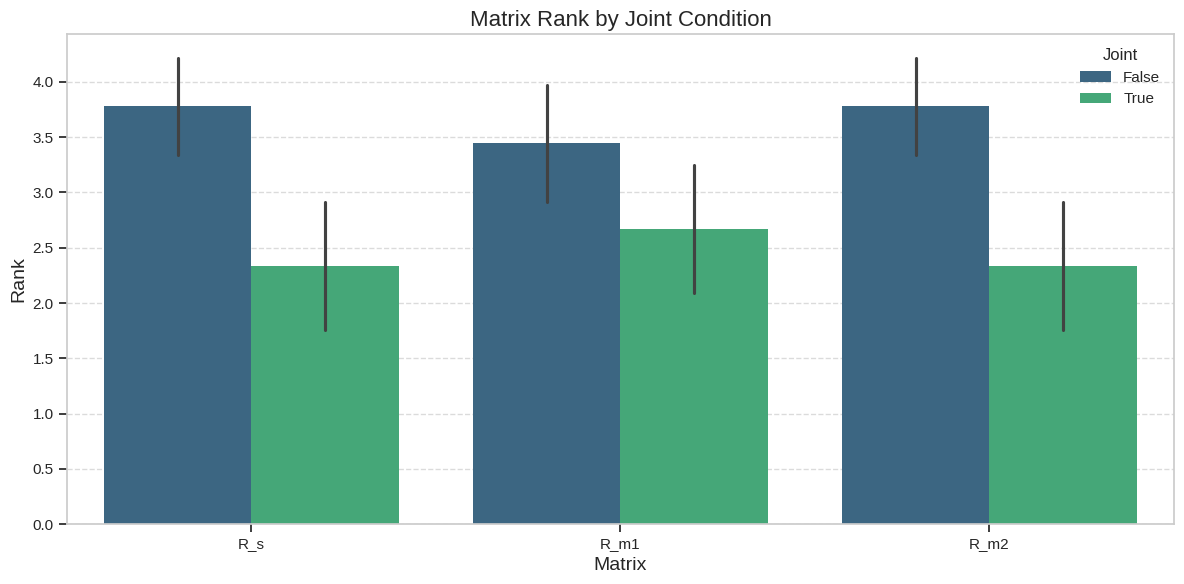

/tmp/ipykernel_809704/1927909385.py:11: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='name', y='value', hue=ablation_param, data=rank_df,


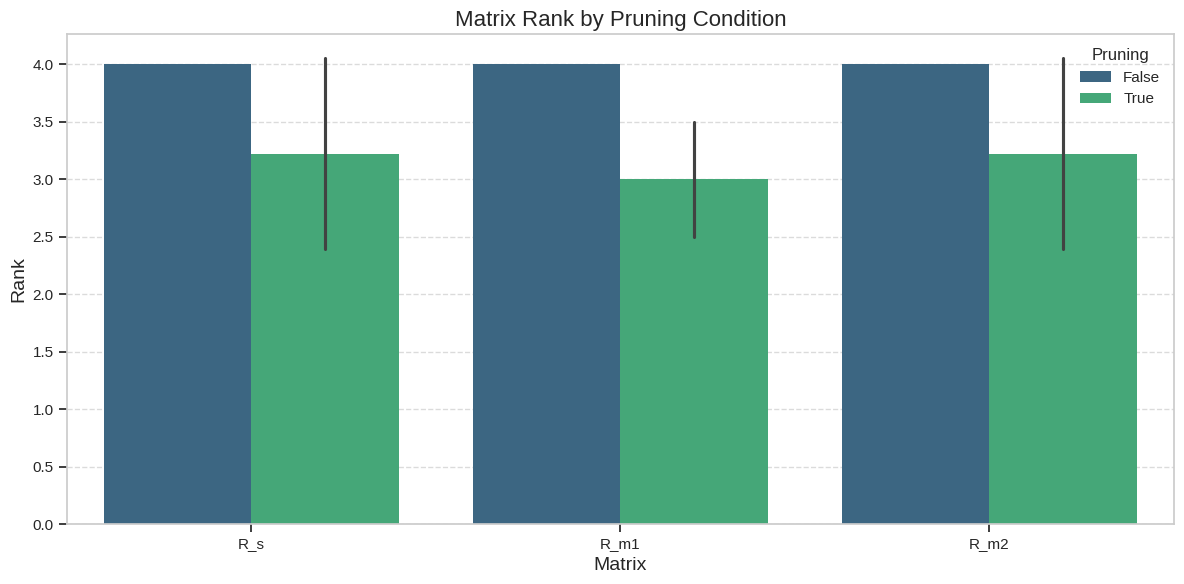

/tmp/ipykernel_809704/1927909385.py:11: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='name', y='value', hue=ablation_param, data=rank_df,


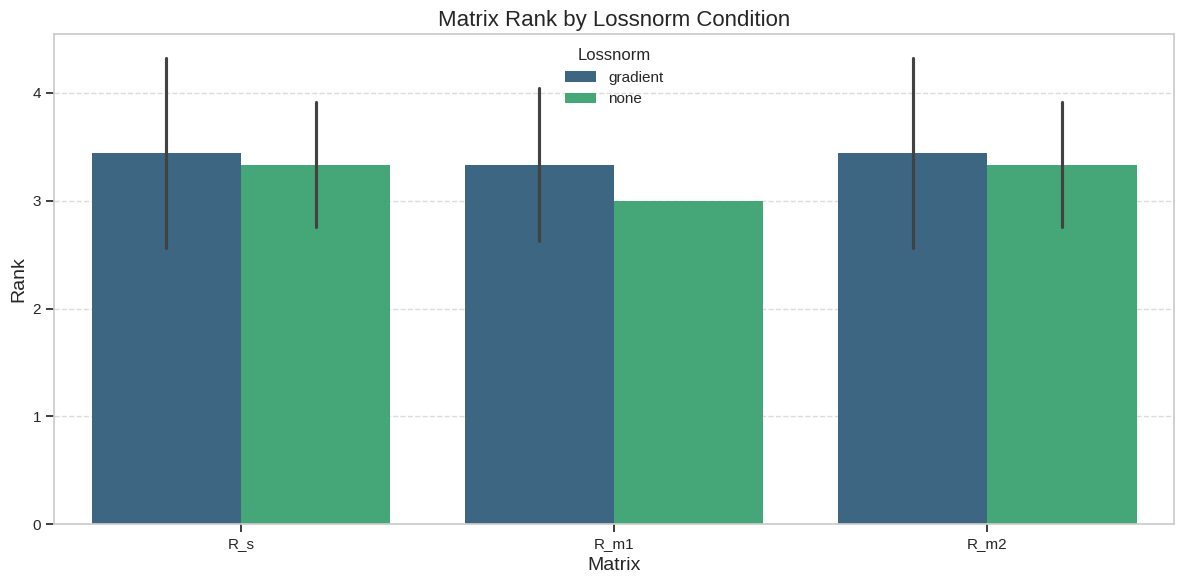

/tmp/ipykernel_809704/1927909385.py:11: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='name', y='value', hue=ablation_param, data=rank_df,


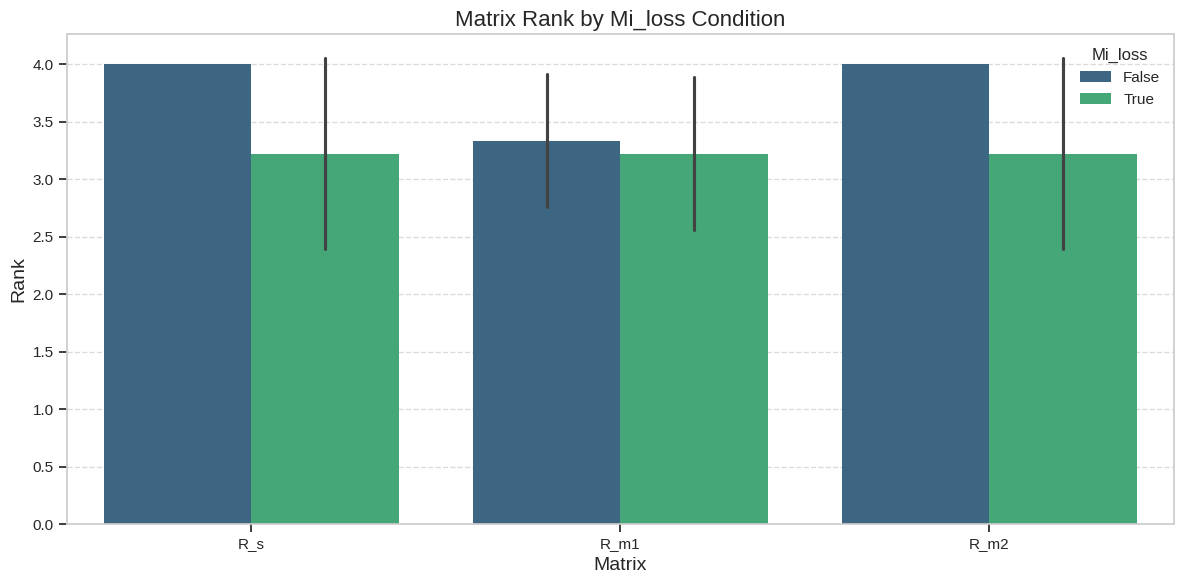

/tmp/ipykernel_809704/1927909385.py:25: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='name', y='value', hue=ablation_param, data=correlation_df,


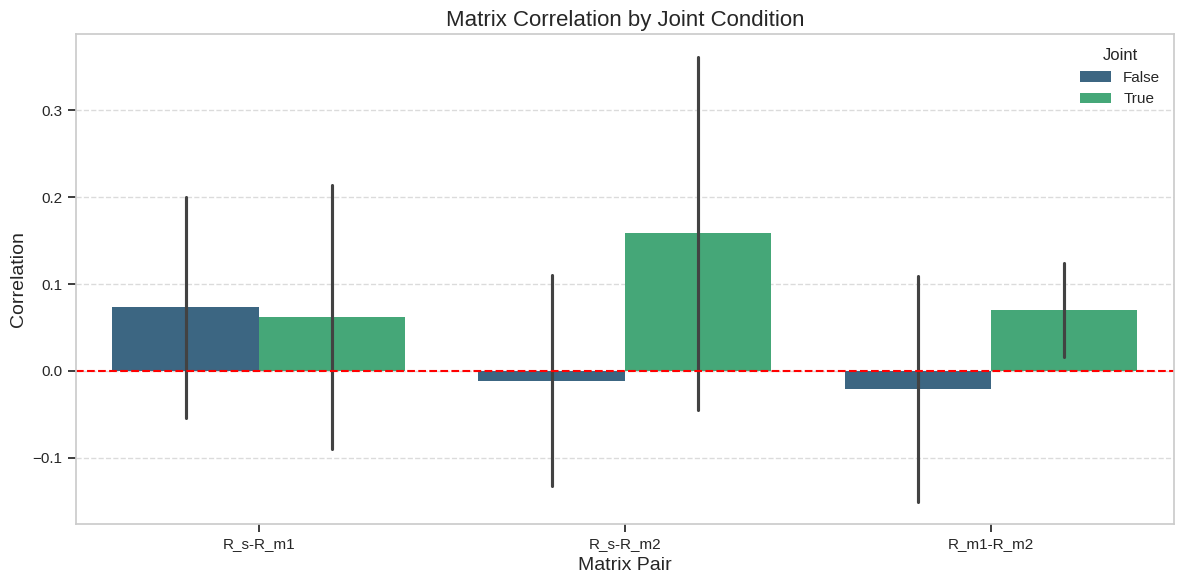

/tmp/ipykernel_809704/1927909385.py:25: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='name', y='value', hue=ablation_param, data=correlation_df,


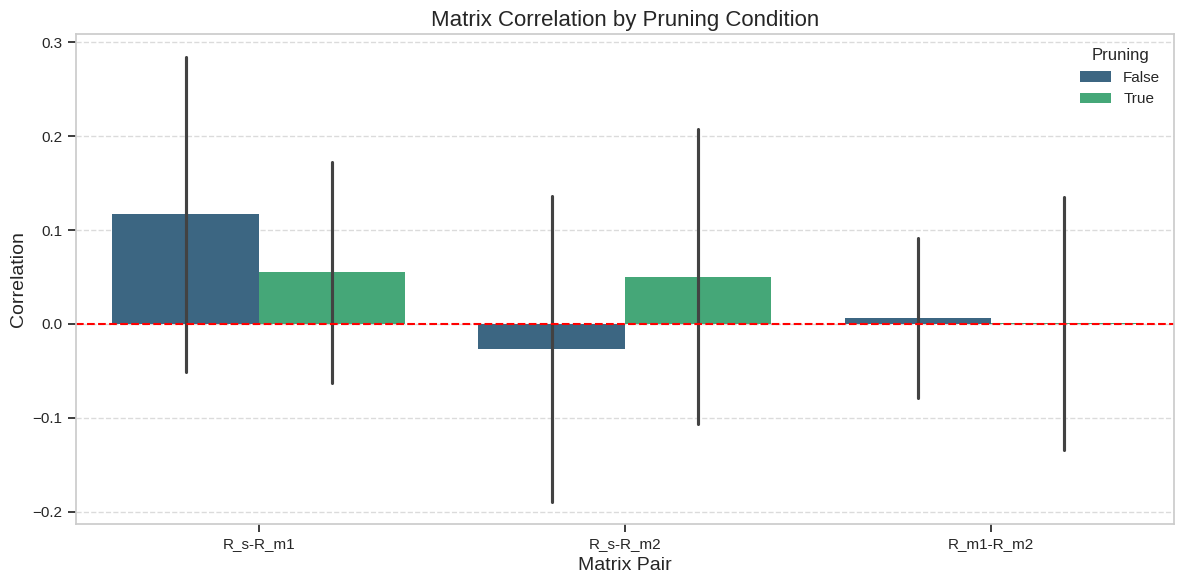

/tmp/ipykernel_809704/1927909385.py:25: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='name', y='value', hue=ablation_param, data=correlation_df,


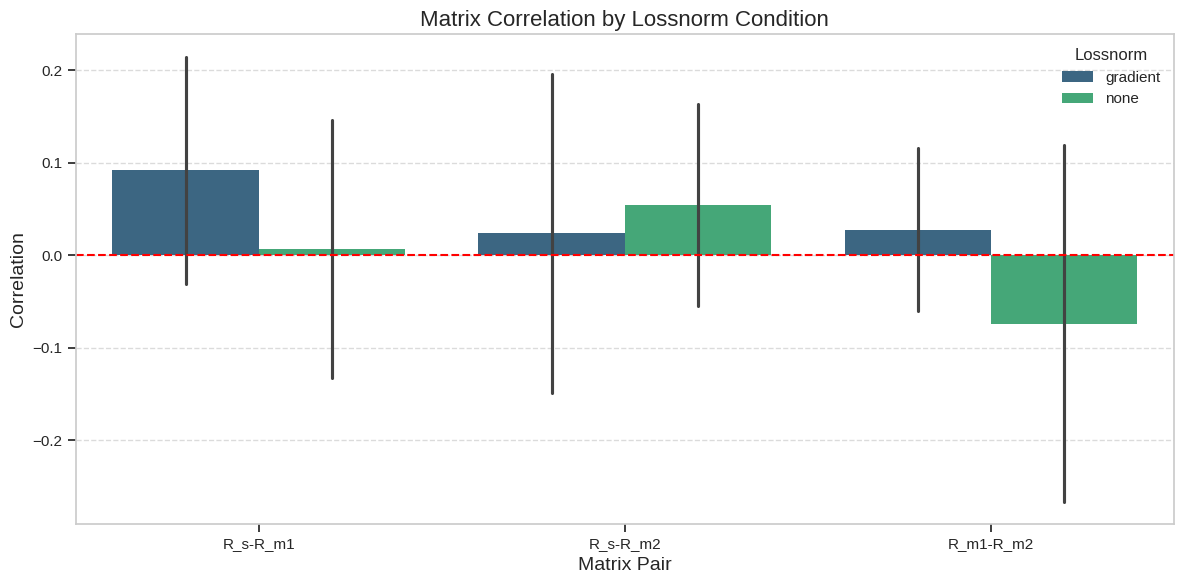

/tmp/ipykernel_809704/1927909385.py:25: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='name', y='value', hue=ablation_param, data=correlation_df,


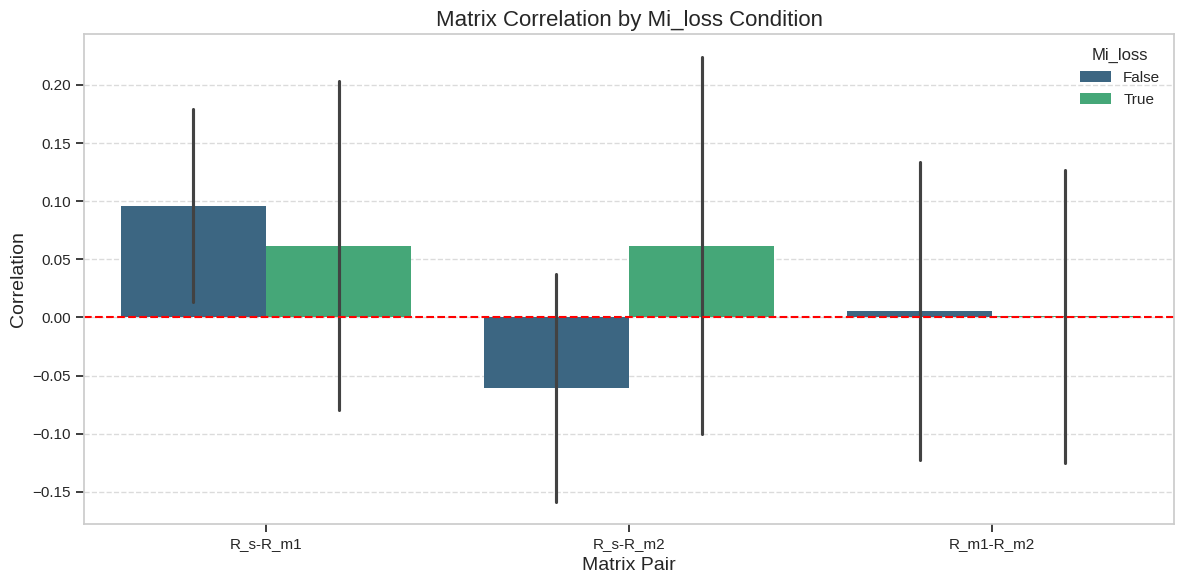

In [15]:
# Plot rank and correlation metrics across ablation conditions
if ablation_rank_correlation_df is not None:
    # Split the dataframe into rank and correlation parts
    rank_df = ablation_rank_correlation_df[ablation_rank_correlation_df['metric'] == 'rank']
    correlation_df = ablation_rank_correlation_df[ablation_rank_correlation_df['metric'] == 'correlation']
    
    # Plot rank by ablation condition
    for ablation_param in ['joint', 'pruning', 'lossnorm', 'mi_loss']:
        if ablation_param in rank_df.columns:
            plt.figure(figsize=(12, 6))
            sns.barplot(x='name', y='value', hue=ablation_param, data=rank_df, 
                        palette='viridis', ci='sd')
            plt.title(f'Matrix Rank by {ablation_param.capitalize()} Condition')
            plt.xlabel('Matrix')
            plt.ylabel('Rank')
            plt.legend(title=ablation_param.capitalize())
            plt.grid(axis='y', linestyle='--', alpha=0.7)
            plt.tight_layout()
            plt.show()
    
    # Plot correlation by ablation condition
    for ablation_param in ['joint', 'pruning', 'lossnorm', 'mi_loss']:
        if ablation_param in correlation_df.columns:
            plt.figure(figsize=(12, 6))
            sns.barplot(x='name', y='value', hue=ablation_param, data=correlation_df, 
                        palette='viridis', ci='sd')
            plt.title(f'Matrix Correlation by {ablation_param.capitalize()} Condition')
            plt.xlabel('Matrix Pair')
            plt.ylabel('Correlation')
            plt.axhline(y=0, color='r', linestyle='--')
            plt.legend(title=ablation_param.capitalize())
            plt.grid(axis='y', linestyle='--', alpha=0.7)
            plt.tight_layout()
            plt.show()
else:
    print("No ablation rank and correlation data available for plotting.")

## 3. Statistical Analysis of Ablation Studies

Let's perform a more detailed statistical analysis to quantify the impact of different ablations.

Statistical Analysis of Ablation Impact on Regression Performance:


,Component,Ablation,Condition1,Condition2,Mean1,Mean2,Difference,Percent_Change,T-statistic,P-value,Significant
0,Zm1,joint,True,False,0.637789,0.702024,-0.064236,-9.150049,-0.709751,0.523721,False
1,Zs1,joint,True,False,0.493187,0.658987,-0.165799,-25.159752,-2.306436,0.049281,True
2,(Zm+Zs)1,joint,True,False,0.641784,0.832206,-0.190422,-22.881596,-2.146848,0.093226,False
3,Zm2,joint,True,False,0.856462,0.822866,0.033595,4.082732,0.707045,0.496795,False
4,Zs2,joint,True,False,0.568913,0.793956,-0.225043,-28.344513,-6.097207,0.000169,True
5,(Zm+Zs)2,joint,True,False,0.867851,0.903159,-0.035308,-3.909352,-1.162931,0.326527,False
6,Zm1,pruning,True,False,0.674907,0.719140,-0.044233,-6.150755,-0.553221,0.607275,False
7,Zs1,pruning,True,False,0.620313,0.609209,0.011103,1.822586,0.051291,0.963366,False
8,(Zm+Zs)1,pruning,True,False,0.757161,0.866921,-0.109760,-12.660934,-0.877051,0.446380,False
9,Zm2,pruning,True,False,0.859510,0.746532,0.112978,15.133712,0.972292,0.431549,False


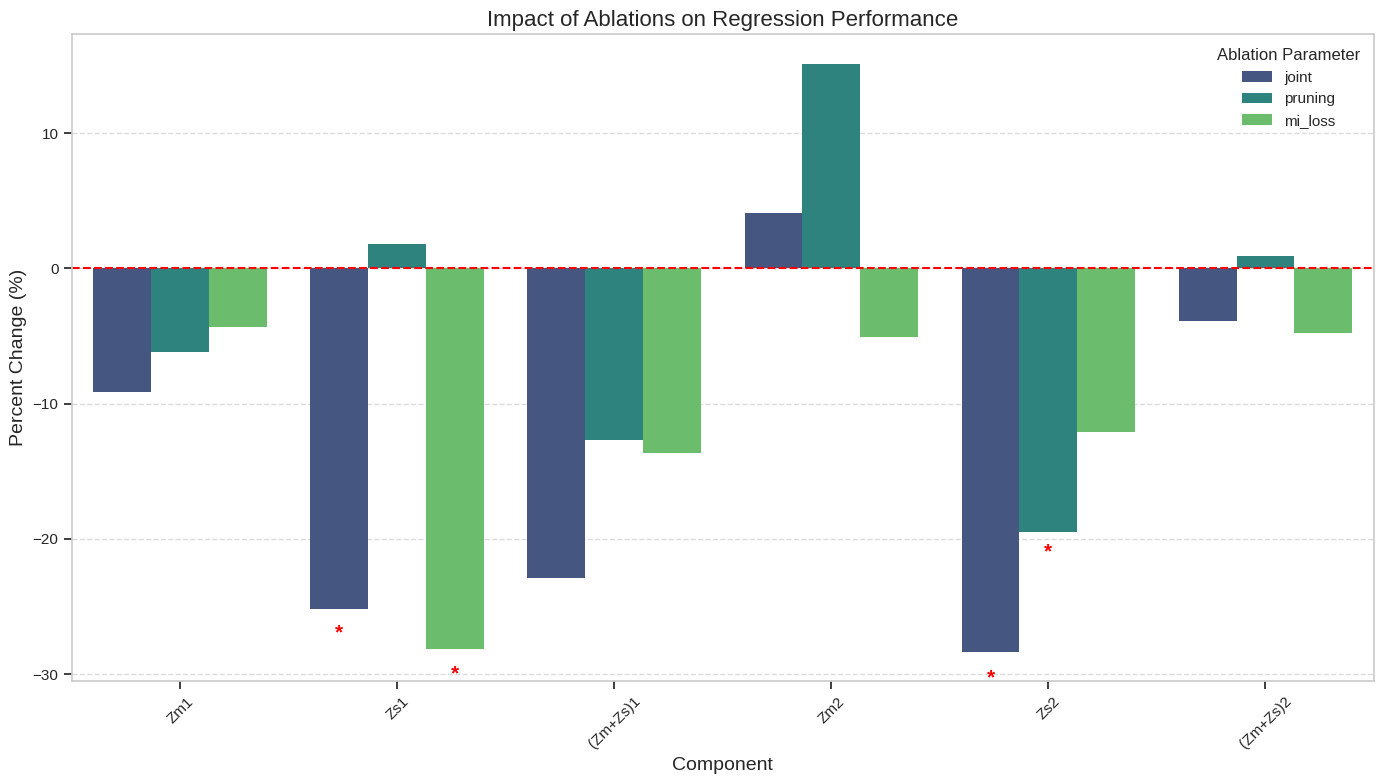

Statistical Analysis of Ablation Impact on Classification Performance:


/home/vschuste/miniconda3/envs/vision_dev/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


,Component,Ablation,Condition1,Condition2,Mean1,Mean2,Difference,Percent_Change,T-statistic,P-value,Significant
0,Zs1,joint,True,False,0.998889,0.985556,0.013333,1.352875,1.918466,0.090872,False
1,Zs2,joint,True,False,1.000000,0.972222,0.027778,2.857143,1.811606,0.107626,False
2,Zm1,joint,True,False,0.999444,0.990926,0.008519,0.859652,2.519839,0.034431,True
3,Zm2,joint,True,False,0.975556,0.959630,0.015926,1.659591,0.704776,0.497663,False
4,Zs1,pruning,True,False,0.993704,0.974444,0.019259,1.976435,1.364264,0.275742,False
5,Zs2,pruning,True,False,0.984444,0.963333,0.021111,2.191465,1.027872,0.337816,False
6,Zm1,pruning,True,False,0.994815,0.987778,0.007037,0.712411,0.959951,0.413761,False
7,Zm2,pruning,True,False,0.975000,0.929444,0.045556,4.901375,0.790024,0.510172,False
8,Zs1,mi_loss,True,False,0.990741,0.983333,0.007407,0.753296,0.441202,0.694187,False
9,Zs2,mi_loss,True,False,0.987593,0.953889,0.033704,3.533295,0.734920,0.535568,False


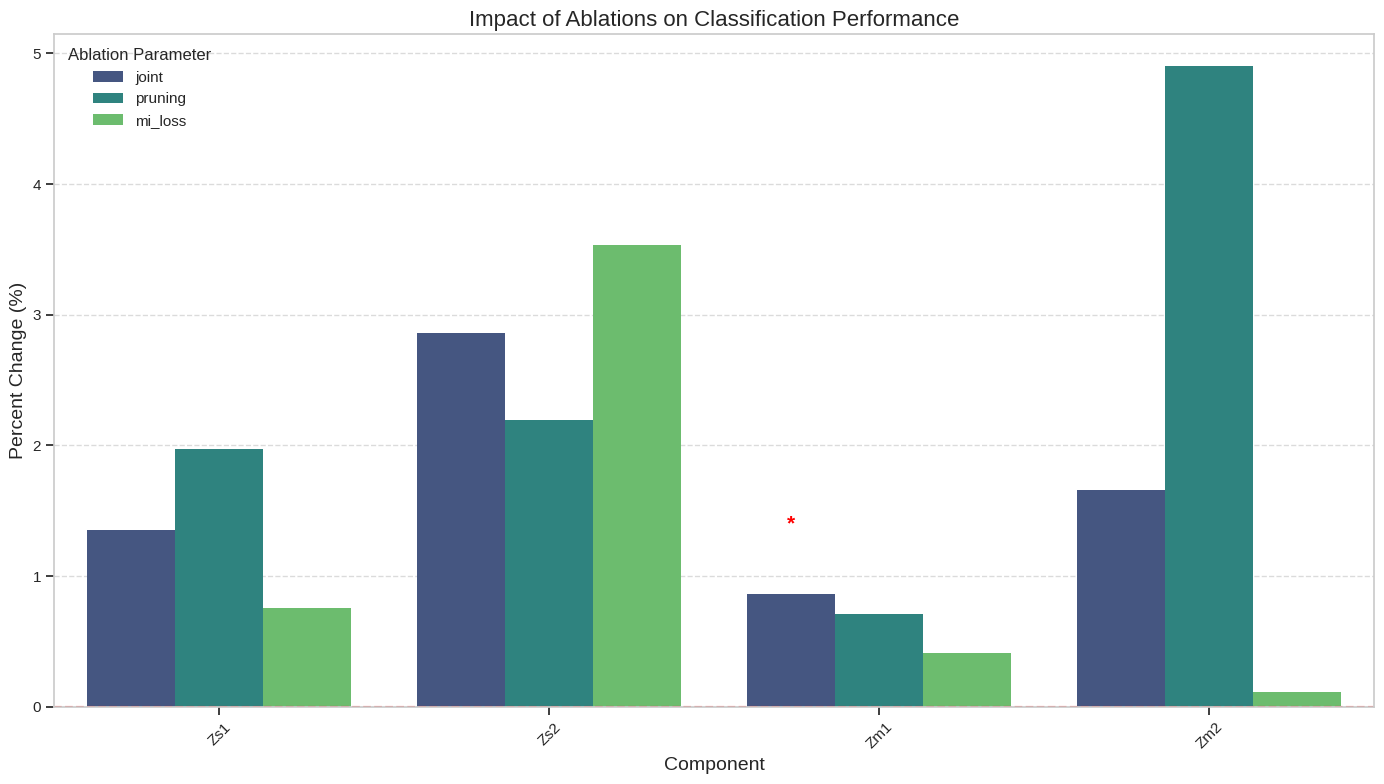

In [19]:
# Perform statistical tests to quantify ablation impacts
from scipy import stats

def analyze_ablation_impact(df, metric_col, ablation_cols):
    """Analyze the impact of ablation parameters on a specific metric"""
    if df is None or metric_col not in df.columns:
        print(f"Missing data or column {metric_col}")
        return
    
    results = []
    for ablation in ablation_cols:
        if ablation in df.columns:
            # Get unique values for this ablation parameter
            values = df[ablation].unique()
            if len(values) < 2:
                print(f"Skipping {ablation} - only one condition found")
                continue
            
            # For each component, compare performance between ablation conditions
            for component in df['name'].unique():
                subset = df[df['name'] == component]
                
                # For boolean ablations, compare True vs False
                if len(values) == 2 and all(isinstance(v, bool) or v in [True, False, 'True', 'False'] for v in values):
                    # Convert string representations to boolean
                    if isinstance(values[0], str):
                        subset = subset.copy()
                        subset[ablation] = subset[ablation].apply(lambda x: x == 'True')
                    
                    group1 = subset[subset[ablation] == True][metric_col]
                    group2 = subset[subset[ablation] == False][metric_col]
                    
                    if len(group1) > 0 and len(group2) > 0:
                        # Perform t-test
                        t_stat, p_val = stats.ttest_ind(group1, group2, equal_var=False)
                        mean_diff = group1.mean() - group2.mean()
                        
                        results.append({
                            'Component': component,
                            'Ablation': ablation,
                            'Condition1': 'True',
                            'Condition2': 'False',
                            'Mean1': group1.mean(),
                            'Mean2': group2.mean(),
                            'Difference': mean_diff,
                            'Percent_Change': (mean_diff / group2.mean()) * 100 if group2.mean() != 0 else float('inf'),
                            'T-statistic': t_stat,
                            'P-value': p_val,
                            'Significant': p_val < 0.05
                        })
    
    return pd.DataFrame(results)

# Add asterisks to mark significant bars
def add_significance_asterisks(ax, data, x_col, y_col, hue_col=None, significance_col='Significant'):
    """Add asterisks above bars to indicate statistical significance"""
    # Get all unique x and hue values
    x_values = data[x_col].unique()
    if hue_col is not None:
        hue_values = data[hue_col].unique()
        width = 0.8 / len(hue_values)  # Width of each bar in a group
    else:
        hue_values = [None]
        width = 0.8  # Width of each bar
    
    # Loop through data to add asterisks for significant results
    for i, x_val in enumerate(x_values):
        for j, hue_val in enumerate(hue_values):
            if hue_col is not None:
                # Filter data for this x value and hue value
                row = data[(data[x_col] == x_val) & (data[hue_col] == hue_val)]
                # Calculate position (center of the corresponding bar)
                pos = i + (j - len(hue_values)/2 + 0.5) * width
            else:
                # Filter data for this x value
                row = data[data[x_col] == x_val]
                pos = i
            
            if not row.empty and row[significance_col].values[0]:
                # Get y value and add asterisk
                y_val = row[y_col].values[0]
                sign = 1 if y_val >= 0 else -1  # Put asterisk above or below based on y value sign
                text_y = y_val + sign * (abs(y_val) * 0.05 + 0.5)  # Small offset from bar
                ax.text(pos, text_y, '*', ha='center', va='center',
                        fontsize=15, fontweight='bold', color='red')

# Analyze regression performance
if ablation_regression_df is not None:
    ablation_cols = ['joint', 'pruning', 'lossnorm', 'mi_loss']
    available_cols = [col for col in ablation_cols if col in ablation_regression_df.columns]
    
    if available_cols:
        regression_impact = analyze_ablation_impact(ablation_regression_df, 'r2_mean', available_cols)
        if regression_impact is not None and not regression_impact.empty:
            print("Statistical Analysis of Ablation Impact on Regression Performance:")
            display(regression_impact)
            
            # Create a visualization of all impacts with asterisks for significant ones
            plt.figure(figsize=(14, 8))
            ax = sns.barplot(x='Component', y='Percent_Change', hue='Ablation', 
                           data=regression_impact, palette='viridis')
            plt.title('Impact of Ablations on Regression Performance')
            plt.xlabel('Component')
            plt.ylabel('Percent Change (%)')
            plt.axhline(y=0, color='r', linestyle='--')
            plt.legend(title='Ablation Parameter')
            plt.xticks(rotation=45)
            plt.grid(axis='y', linestyle='--', alpha=0.7)
            
            # Add asterisks to significant bars
            add_significance_asterisks(ax, regression_impact, 'Component', 'Percent_Change', 'Ablation')
            
            plt.tight_layout()
            plt.show()

# Analyze classification performance
if ablation_classification_df is not None:
    ablation_cols = ['joint', 'pruning', 'lossnorm', 'mi_loss']
    available_cols = [col for col in ablation_cols if col in ablation_classification_df.columns]
    
    if available_cols:
        classification_impact = analyze_ablation_impact(ablation_classification_df, 'accuracy', available_cols)
        if classification_impact is not None and not classification_impact.empty:
            print("Statistical Analysis of Ablation Impact on Classification Performance:")
            display(classification_impact)
            
            # Create a visualization of all impacts with asterisks for significant ones
            plt.figure(figsize=(14, 8))
            ax = sns.barplot(x='Component', y='Percent_Change', hue='Ablation', 
                           data=classification_impact, palette='viridis')
            plt.title('Impact of Ablations on Classification Performance')
            plt.xlabel('Component')
            plt.ylabel('Percent Change (%)')
            plt.axhline(y=0, color='r', linestyle='--')
            plt.legend(title='Ablation Parameter')
            plt.xticks(rotation=45)
            plt.grid(axis='y', linestyle='--', alpha=0.7)
            
            # Add asterisks to significant bars
            add_significance_asterisks(ax, classification_impact, 'Component', 'Percent_Change', 'Ablation')
            
            plt.tight_layout()
            plt.show()

## 4. Summary and Conclusions

### Key Findings from Rank Pruning Experiments:
- How matrix ranks evolve during training (converge to certain values regardless of initialization?)
- Impact of pruning on final representations
- Relationship between initial and final ranks

### Key Findings from Ablation Studies:
- Impact of Joint vs. Staged Training
- Effect of Pruning on Performance
- Importance of Loss Normalization
- Mutual Information Loss vs. Reconstruction Loss

### Recommendations for Model Design:
- Optimal rank initialization strategy
- Whether to use pruning
- Best training schedule (joint vs. staged)
- Preferred loss formulation